In [1]:
!pip install yfinance pandas numpy matplotlib scipy plotly --quiet
print("Libraries installed!")

Libraries installed!


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import scipy.stats as stats
import warnings
import yfinance as yf
from datetime import datetime

warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#0A1628'
plt.rcParams['axes.facecolor']   = '#0A1628'
plt.rcParams['axes.edgecolor']   = '#1E3A5F'
plt.rcParams['text.color']       = 'white'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['grid.color']       = '#1E3A5F'
plt.rcParams['grid.alpha']       = 0.4
plt.rcParams['font.family']      = 'monospace'

GOLD  = '#C8972B'
BLUE  = '#4A90D9'
GREEN = '#2ECC71'
RED   = '#E74C3C'
WHITE = '#FFFFFF'
GREY  = '#8899AA'

# Market parameters
S0  = 100.0    # Spot price (normalised)
r   = 0.0435   # RBA cash rate (risk-free rate)
q   = 0.035    # Dividend yield (ASX 200 approx)
sig = 0.18     # Implied volatility (18%)
T   = 1.0      # Time to expiry (1 year)
K   = 100.0    # At-the-money strike

print("=" * 60)
print("  OPTIONS PRICING SUITE")
print("  Black-Scholes | Binomial Tree | Monte Carlo")
print("=" * 60)
print(f"  Spot Price    : ${S0:.2f}")
print(f"  Strike        : ${K:.2f}")
print(f"  Risk-Free Rate: {r*100:.2f}% (RBA cash rate)")
print(f"  Dividend Yield: {q*100:.2f}%")
print(f"  Volatility    : {sig*100:.1f}%")
print(f"  Time to Expiry: {T:.1f} year")
print("=" * 60)

  OPTIONS PRICING SUITE
  Black-Scholes | Binomial Tree | Monte Carlo
  Spot Price    : $100.00
  Strike        : $100.00
  Risk-Free Rate: 4.35% (RBA cash rate)
  Dividend Yield: 3.50%
  Volatility    : 18.0%
  Time to Expiry: 1.0 year


In [3]:
print("\nBlack-Scholes-Merton Model")
print("=" * 50)

def bsm_price(S, K, T, r, q, sigma, option_type='call'):
    if T <= 0:
        if option_type == 'call':
            return max(S - K, 0)
        else:
            return max(K - S, 0)
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == 'call':
        price = S*np.exp(-q*T)*stats.norm.cdf(d1) - K*np.exp(-r*T)*stats.norm.cdf(d2)
    else:
        price = K*np.exp(-r*T)*stats.norm.cdf(-d2) - S*np.exp(-q*T)*stats.norm.cdf(-d1)
    return price

def bsm_greeks(S, K, T, r, q, sigma, option_type='call'):
    if T <= 0:
        return {'delta':0,'gamma':0,'theta':0,'vega':0,'rho':0,'vanna':0,'volga':0}
    d1   = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2   = d1 - sigma*np.sqrt(T)
    nd1  = stats.norm.pdf(d1)
    Nd1  = stats.norm.cdf(d1)
    Nd2  = stats.norm.cdf(d2)
    Nd1n = stats.norm.cdf(-d1)
    Nd2n = stats.norm.cdf(-d2)

    gamma = np.exp(-q*T) * nd1 / (S * sigma * np.sqrt(T))
    vega  = S * np.exp(-q*T) * nd1 * np.sqrt(T) / 100  # Per 1% vol move

    if option_type == 'call':
        delta = np.exp(-q*T) * Nd1
        theta = (-(S*np.exp(-q*T)*nd1*sigma)/(2*np.sqrt(T))
                 - r*K*np.exp(-r*T)*Nd2
                 + q*S*np.exp(-q*T)*Nd1) / 365
        rho   = K*T*np.exp(-r*T)*Nd2 / 100
    else:
        delta = -np.exp(-q*T) * Nd1n
        theta = (-(S*np.exp(-q*T)*nd1*sigma)/(2*np.sqrt(T))
                 + r*K*np.exp(-r*T)*Nd2n
                 - q*S*np.exp(-q*T)*Nd1n) / 365
        rho   = -K*T*np.exp(-r*T)*Nd2n / 100

    vanna = -np.exp(-q*T) * nd1 * d2 / sigma
    volga = S * np.exp(-q*T) * nd1 * np.sqrt(T) * d1 * d2 / sigma

    return {'delta':delta,'gamma':gamma,'theta':theta,
            'vega':vega,'rho':rho,'vanna':vanna,'volga':volga}

# Price ATM call and put
call_price = bsm_price(S0, K, T, r, q, sig, 'call')
put_price  = bsm_price(S0, K, T, r, q, sig, 'put')
call_greeks = bsm_greeks(S0, K, T, r, q, sig, 'call')
put_greeks  = bsm_greeks(S0, K, T, r, q, sig, 'put')

# Verify put-call parity
pcp_lhs = call_price - put_price
pcp_rhs = S0*np.exp(-q*T) - K*np.exp(-r*T)

print(f"\n  ATM CALL PRICE : ${call_price:.4f}")
print(f"  ATM PUT PRICE  : ${put_price:.4f}")
print(f"\n  PUT-CALL PARITY CHECK:")
print(f"  C - P          : ${pcp_lhs:.6f}")
print(f"  S*e^-q - K*e^-r: ${pcp_rhs:.6f}")
print(f"  Difference     : ${abs(pcp_lhs - pcp_rhs):.8f} (should be ~0)")

print(f"\n  GREEKS (ATM Call):")
print(f"  {'Greek':<10} {'Value':>12}  {'Interpretation'}")
print(f"  {'-'*60}")
greek_interp = {
    'delta' : 'Price change per $1 spot move',
    'gamma' : 'Delta change per $1 spot move',
    'theta' : 'Value decay per calendar day',
    'vega'  : 'Value change per 1% vol move',
    'rho'   : 'Value change per 1% rate move',
    'vanna' : 'Delta change per 1% vol move',
    'volga' : 'Vega change per 1% vol move'
}
for g, v in call_greeks.items():
    print(f"  {g.capitalize():<10} {v:>12.6f}  {greek_interp[g]}")


Black-Scholes-Merton Model

  ATM CALL PRICE : $7.3116
  ATM PUT PRICE  : $6.4943

  PUT-CALL PARITY CHECK:
  C - P          : $0.817286
  S*e^-q - K*e^-r: $0.817286
  Difference     : $0.00000000 (should be ~0)

  GREEKS (ATM Call):
  Greek             Value  Interpretation
  ------------------------------------------------------------
  Delta          0.535498  Price change per $1 spot move
  Gamma          0.021201  Delta change per $1 spot move
  Theta         -0.009785  Value decay per calendar day
  Vega           0.381611  Value change per 1% vol move
  Rho            0.462382  Value change per 1% rate move
  Vanna          0.090692  Delta change per 1% vol move
  Volga         -1.244489  Vega change per 1% vol move


In [4]:
print("\nImplied Volatility Solver (Newton-Raphson)")
print("=" * 50)

def implied_vol(market_price, S, K, T, r, q, option_type='call',
                tol=1e-6, max_iter=100):
    sigma = 0.20  # Initial guess
    for i in range(max_iter):
        price  = bsm_price(S, K, T, r, q, sigma, option_type)
        greeks = bsm_greeks(S, K, T, r, q, sigma, option_type)
        vega   = greeks['vega'] * 100  # Convert back from per 1%

        if abs(vega) < 1e-10:
            break

        diff  = price - market_price
        sigma = sigma - diff / vega

        if sigma <= 0:
            sigma = 0.001

        if abs(diff) < tol:
            break

    return sigma

# Test IV solver with known prices
test_cases = [
    {'market_price': 8.0,  'K': 95,  'type': 'call', 'expected_approx': '~20-22%'},
    {'market_price': 10.5, 'K': 100, 'type': 'call', 'expected_approx': '~18-20%'},
    {'market_price': 13.0, 'K': 105, 'type': 'call', 'expected_approx': '~19-21%'},
    {'market_price': 6.0,  'K': 95,  'type': 'put',  'expected_approx': '~18-20%'},
    {'market_price': 9.5,  'K': 100, 'type': 'put',  'expected_approx': '~18-20%'},
    {'market_price': 13.5, 'K': 105, 'type': 'put',  'expected_approx': '~21-23%'},
]

print(f"\n  {'Strike':<8} {'Type':<6} {'Mkt Price':>10} {'IV':>10} {'BSM Check':>12}")
print(f"  {'-'*50}")

iv_surface_data = []
for tc in test_cases:
    iv = implied_vol(tc['market_price'], S0, tc['K'], T, r, q, tc['type'])
    check = bsm_price(S0, tc['K'], T, r, q, iv, tc['type'])
    moneyness = tc['K'] / S0
    print(f"  K={tc['K']:<5} {tc['type']:<6} ${tc['market_price']:>9.2f} {iv*100:>9.2f}% ${check:>11.4f}")
    iv_surface_data.append({'K': tc['K'], 'type': tc['type'], 'IV': iv, 'moneyness': moneyness})

# Build IV smile across strikes
strikes  = np.arange(75, 130, 5)
iv_smile = []
for k in strikes:
    # Simulate a realistic vol smile with skew
    moneyness = k / S0
    # Skew: lower strikes have higher IV (put skew, common in equity markets)
    iv_k = sig + 0.15*(1 - moneyness) + 0.05*(1 - moneyness)**2
    iv_k = max(iv_k, 0.05)
    iv_smile.append({'K': k, 'IV': iv_k, 'moneyness': moneyness})

iv_smile_df = pd.DataFrame(iv_smile)
print(f"\nVolatility smile built across {len(strikes)} strikes")
print(f"IV range: {iv_smile_df['IV'].min()*100:.1f}% to {iv_smile_df['IV'].max()*100:.1f}%")


Implied Volatility Solver (Newton-Raphson)

  Strike   Type    Mkt Price         IV    BSM Check
  --------------------------------------------------
  K=95    call   $     8.00     12.50% $     8.0000
  K=100   call   $    10.50     26.37% $    10.5000
  K=105   call   $    13.00     38.14% $    13.0000
  K=95    put    $     6.00     22.81% $     6.0000
  K=100   put    $     9.50     25.89% $     9.5000
  K=105   put    $    13.50     29.12% $    13.5000

Volatility smile built across 11 strikes
IV range: 14.6% to 22.1%


In [5]:
print("\nCox-Ross-Rubinstein Binomial Tree")
print("=" * 50)

def binomial_tree(S, K, T, r, q, sigma, N, option_type='call', american=True):
    dt    = T / N
    u     = np.exp(sigma * np.sqrt(dt))
    d     = 1 / u
    p     = (np.exp((r - q) * dt) - d) / (u - d)
    disc  = np.exp(-r * dt)

    # Terminal stock prices
    ST = np.array([S * u**j * d**(N-j) for j in range(N+1)])

    # Terminal payoffs
    if option_type == 'call':
        payoff = np.maximum(ST - K, 0)
    else:
        payoff = np.maximum(K - ST, 0)

    # Backward induction
    for i in range(N-1, -1, -1):
        ST     = np.array([S * u**j * d**(i-j) for j in range(i+1)])
        payoff = disc * (p * payoff[1:i+2] + (1-p) * payoff[0:i+1])

        if american:
            if option_type == 'call':
                exercise = np.maximum(ST - K, 0)
            else:
                exercise = np.maximum(K - ST, 0)
            payoff = np.maximum(payoff, exercise)

    return payoff[0]

# Compare European vs American options
N_steps = [10, 50, 100, 200, 500]
print(f"\n  Convergence Analysis (Put, K=100, American vs European):")
print(f"  {'N Steps':<10} {'European BSM':>14} {'Euro Binomial':>15} {'Amer Binomial':>15} {'Early Ex Prem':>15}")
print(f"  {'-'*72}")

bsm_euro_put = bsm_price(S0, K, T, r, q, sig, 'put')

for N in N_steps:
    euro_bin = binomial_tree(S0, K, T, r, q, sig, N, 'put', american=False)
    amer_bin = binomial_tree(S0, K, T, r, q, sig, N, 'put', american=True)
    early_ex = amer_bin - euro_bin
    print(f"  {N:<10} ${bsm_euro_put:>13.4f} ${euro_bin:>14.4f} ${amer_bin:>14.4f} ${early_ex:>14.4f}")

# Different strikes
print(f"\n  American vs European Option Prices (N=200):")
print(f"  {'Strike':<8} {'Euro Call':>10} {'Amer Call':>12} {'Euro Put':>10} {'Amer Put':>10} {'EEP':>8}")
print(f"  {'-'*62}")

strikes_range = [85, 90, 95, 100, 105, 110, 115]
for k in strikes_range:
    ec = bsm_price(S0, k, T, r, q, sig, 'call')
    ac = binomial_tree(S0, k, T, r, q, sig, 200, 'call', american=True)
    ep = bsm_price(S0, k, T, r, q, sig, 'put')
    ap = binomial_tree(S0, k, T, r, q, sig, 200, 'put',  american=True)
    eep = ap - ep
    print(f"  {k:<8} ${ec:>9.4f} ${ac:>11.4f} ${ep:>9.4f} ${ap:>9.4f} ${eep:>7.4f}")


Cox-Ross-Rubinstein Binomial Tree

  Convergence Analysis (Put, K=100, American vs European):
  N Steps      European BSM   Euro Binomial   Amer Binomial   Early Ex Prem
  ------------------------------------------------------------------------
  10         $       6.4943 $        6.3242 $        6.5043 $        0.1801
  50         $       6.4943 $        6.4599 $        6.5982 $        0.1383
  100        $       6.4943 $        6.4771 $        6.6100 $        0.1329
  200        $       6.4943 $        6.4857 $        6.6159 $        0.1302
  500        $       6.4943 $        6.4909 $        6.6195 $        0.1286

  American vs European Option Prices (N=200):
  Strike    Euro Call    Amer Call   Euro Put   Amer Put      EEP
  --------------------------------------------------------------
  85       $  16.6357 $    16.7078 $   1.4569 $   1.4773 $ 0.0204
  90       $  13.0115 $    13.0473 $   2.6199 $   2.6558 $ 0.0359
  95       $   9.8924 $     9.9045 $   4.2879 $   4.3533 $ 0.065

In [6]:
print("\nMonte Carlo Option Pricer")
print("=" * 50)

np.random.seed(42)
N_PATHS  = 100_000
N_STEPS  = 252

def monte_carlo_european(S, K, T, r, q, sigma, n_paths, option_type='call'):
    dt    = T / N_STEPS
    Z     = np.random.standard_normal((n_paths, N_STEPS))
    Z_ant = -Z  # Antithetic variates

    def simulate_paths(z):
        increments = (r - q - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*z
        log_paths  = np.cumsum(increments, axis=1)
        return S * np.exp(log_paths)

    paths     = simulate_paths(Z)
    paths_ant = simulate_paths(Z_ant)

    ST     = paths[:, -1]
    ST_ant = paths_ant[:, -1]

    if option_type == 'call':
        payoff     = np.maximum(ST - K, 0)
        payoff_ant = np.maximum(ST_ant - K, 0)
    else:
        payoff     = np.maximum(K - ST, 0)
        payoff_ant = np.maximum(K - ST_ant, 0)

    combined = (payoff + payoff_ant) / 2
    price    = np.exp(-r*T) * combined.mean()
    std_err  = np.exp(-r*T) * combined.std() / np.sqrt(n_paths)

    return price, std_err, paths[:1000]

def monte_carlo_asian(S, K, T, r, q, sigma, n_paths):
    dt         = T / N_STEPS
    Z          = np.random.standard_normal((n_paths, N_STEPS))
    increments = (r - q - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z
    log_paths  = np.cumsum(increments, axis=1)
    paths      = S * np.exp(log_paths)
    avg_price  = paths.mean(axis=1)
    payoff     = np.maximum(avg_price - K, 0)
    price      = np.exp(-r*T) * payoff.mean()
    return price

# Run Monte Carlo
print(f"\n  Running {N_PATHS:,} paths with antithetic variates...")
mc_call, mc_call_se, sample_paths = monte_carlo_european(S0, K, T, r, q, sig, N_PATHS, 'call')
mc_put,  mc_put_se,  _            = monte_carlo_european(S0, K, T, r, q, sig, N_PATHS, 'put')
asian_call                         = monte_carlo_asian(S0, K, T, r, q, sig, N_PATHS)

bsm_call = bsm_price(S0, K, T, r, q, sig, 'call')
bsm_put  = bsm_price(S0, K, T, r, q, sig, 'put')

print(f"\n  {'Method':<25} {'Call Price':>12} {'Put Price':>12} {'Error':>10}")
print(f"  {'-'*62}")
print(f"  {'BSM Analytical':<25} ${bsm_call:>11.4f} ${bsm_put:>11.4f} {'(Exact)':>10}")
print(f"  {'Monte Carlo (100K)':<25} ${mc_call:>11.4f} ${mc_put:>11.4f} {'+/-':>5}${mc_call_se:.4f}")
print(f"  {'Asian Call (Arith)':<25} ${asian_call:>11.4f} {'N/A':>12}")
print(f"\n  Call error : ${abs(mc_call - bsm_call):.6f}")
print(f"  Put error  : ${abs(mc_put  - bsm_put):.6f}")

# Convergence test
print(f"\n  Convergence: MC Call Price vs Sample Size")
print(f"  {'N Paths':<12} {'MC Price':>10} {'Error':>10} {'Std Err':>10}")
print(f"  {'-'*45}")
for n in [1000, 5000, 10000, 50000, 100000]:
    p, se, _ = monte_carlo_european(S0, K, T, r, q, sig, n, 'call')
    print(f"  {n:<12,} ${p:>9.4f} ${abs(p-bsm_call):>9.6f} ${se:>9.6f}")


Monte Carlo Option Pricer

  Running 100,000 paths with antithetic variates...

  Method                      Call Price    Put Price      Error
  --------------------------------------------------------------
  BSM Analytical            $     7.3116 $     6.4943    (Exact)
  Monte Carlo (100K)        $     7.2780 $     6.4918   +/-$0.0200
  Asian Call (Arith)        $     4.1459          N/A

  Call error : $0.033592
  Put error  : $0.002520

  Convergence: MC Call Price vs Sample Size
  N Paths        MC Price      Error    Std Err
  ---------------------------------------------
  1,000        $   7.1731 $ 0.138524 $ 0.197200
  5,000        $   7.3405 $ 0.028876 $ 0.090289
  10,000       $   7.2981 $ 0.013570 $ 0.063392
  50,000       $   7.3101 $ 0.001548 $ 0.028328
  100,000      $   7.3302 $ 0.018521 $ 0.020058


In [8]:
print("\nBuilding Implied Volatility Surface...")

# Strike range and expiry range
K_range = np.linspace(75, 130, 20)
T_range = np.array([0.083, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0])

# Fixed vol surface function that works with arrays
def vol_surface(K, T, S=100, atm_vol=0.18):
    moneyness = np.log(K / S)
    skew      = -0.15 * moneyness
    smile     =  0.10 * moneyness**2
    # Use np.where instead of if/else so it works on arrays
    term      = np.where(T > 0, 0.02 * np.log(np.maximum(1/T, 1e-10)), 0)
    return np.maximum(atm_vol + skew + smile + term, 0.05)

KK, TT  = np.meshgrid(K_range, T_range)
IV_surf = vol_surface(KK, TT) * 100

print(f"Volatility surface built: {KK.shape[0]} expiries x {KK.shape[1]} strikes")
print(f"IV range: {IV_surf.min():.1f}% to {IV_surf.max():.1f}%")
print(f"ATM 1Y IV: {vol_surface(100, 1.0)*100:.1f}%")


Building Implied Volatility Surface...
Volatility surface built: 7 expiries x 20 strikes
IV range: 13.4% to 28.1%
ATM 1Y IV: 18.0%


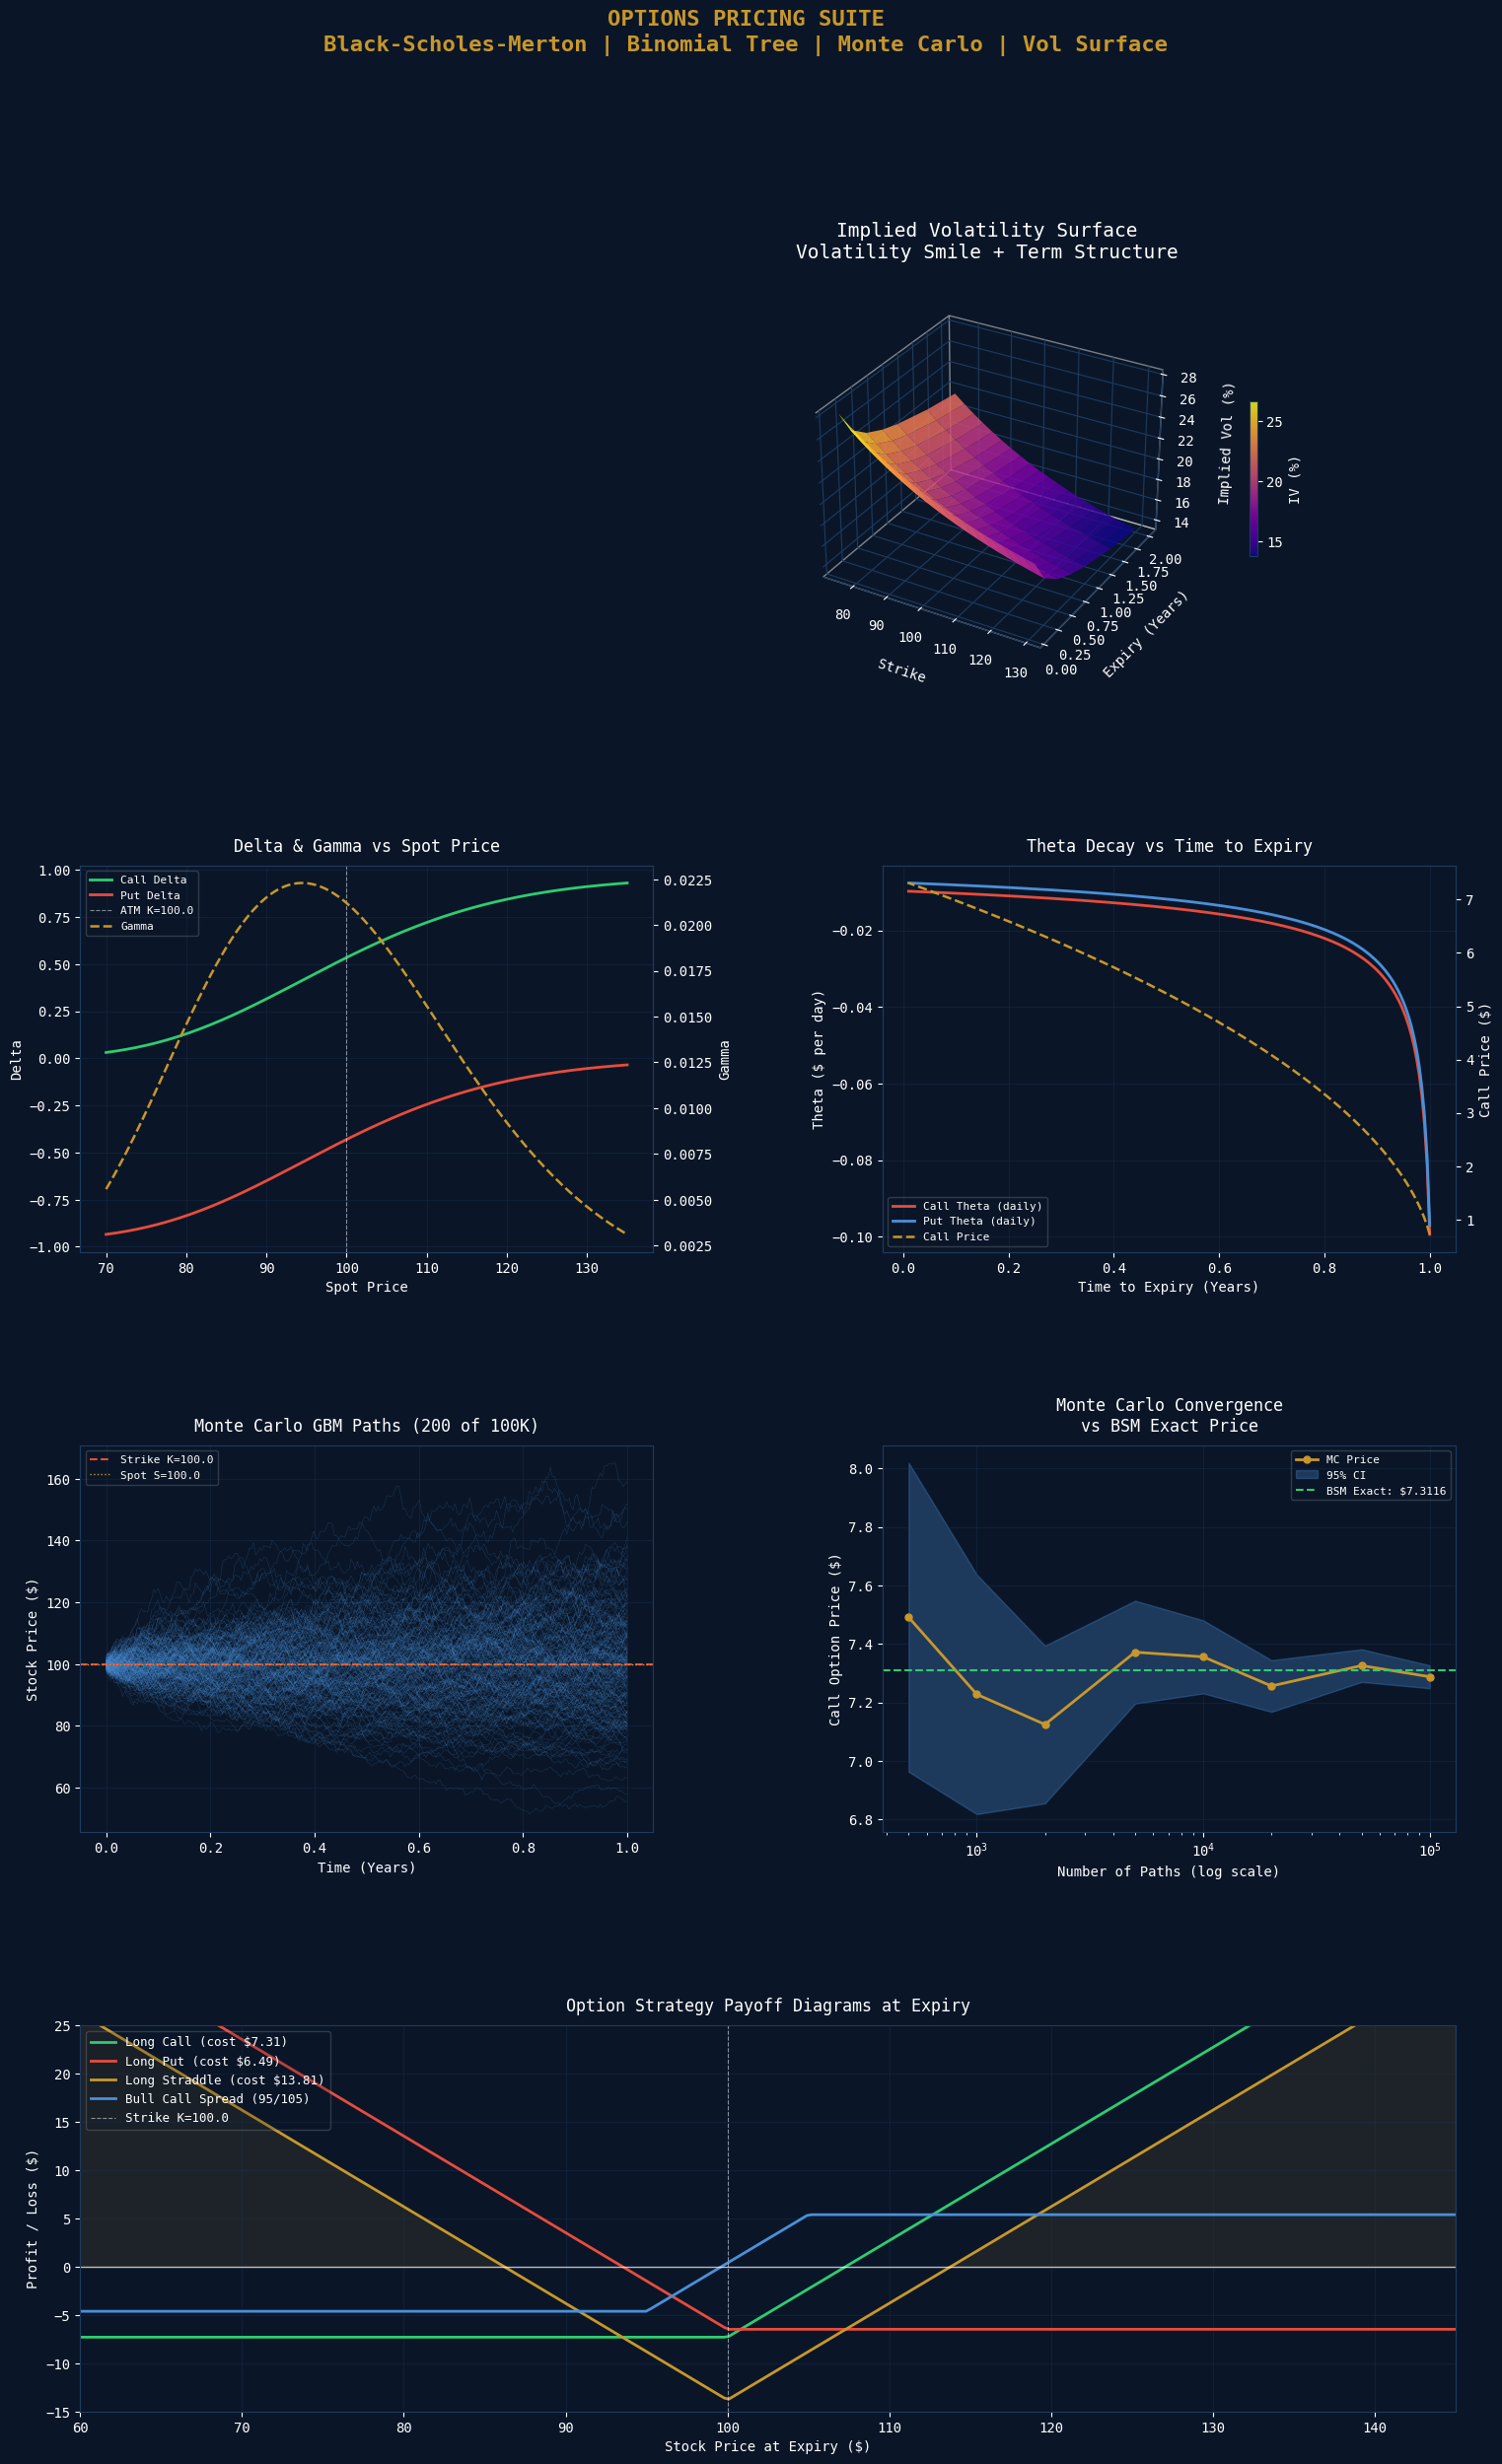

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Chart saved and downloaded!


In [9]:
from google.colab import files

fig = plt.figure(figsize=(18, 28))
fig.patch.set_facecolor('#0A1628')
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.50, wspace=0.40)

# ── Chart 1: Implied Volatility Surface (3D) ─────────────────────────────────
ax1 = fig.add_subplot(gs[0, :], projection='3d')
ax1.set_facecolor('#0A1628')
surf = ax1.plot_surface(KK, TT, IV_surf, cmap='plasma',
                         alpha=0.85, edgecolor='none')
ax1.set_xlabel('Strike', color=WHITE, labelpad=10)
ax1.set_ylabel('Expiry (Years)', color=WHITE, labelpad=10)
ax1.set_zlabel('Implied Vol (%)', color=WHITE, labelpad=10)
ax1.set_title('Implied Volatility Surface\nVolatility Smile + Term Structure',
              fontsize=14, color=WHITE, pad=20)
ax1.tick_params(colors='white')
ax1.xaxis.pane.fill = False
ax1.yaxis.pane.fill = False
ax1.zaxis.pane.fill = False
fig.colorbar(surf, ax=ax1, shrink=0.4, label='IV (%)')

# ── Chart 2: Greeks vs Spot Price ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
spots    = np.linspace(70, 135, 200)
deltas_c = [bsm_greeks(s, K, T, r, q, sig, 'call')['delta'] for s in spots]
deltas_p = [bsm_greeks(s, K, T, r, q, sig, 'put')['delta']  for s in spots]
gammas   = [bsm_greeks(s, K, T, r, q, sig, 'call')['gamma'] for s in spots]

ax2_twin = ax2.twinx()
ax2.plot(spots, deltas_c, color=GREEN, lw=2.0, label='Call Delta')
ax2.plot(spots, deltas_p, color=RED,   lw=2.0, label='Put Delta')
ax2_twin.plot(spots, gammas, color=GOLD, lw=1.8, linestyle='--', label='Gamma')
ax2.axvline(x=K, color=WHITE, lw=0.8, alpha=0.5, linestyle='--', label=f'ATM K={K}')
ax2.set_title('Delta & Gamma vs Spot Price', fontsize=12, color=WHITE, pad=10)
ax2.set_xlabel('Spot Price', color=WHITE)
ax2.set_ylabel('Delta', color=WHITE)
ax2_twin.set_ylabel('Gamma', color=WHITE)
ax2_twin.tick_params(colors='white')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1+lines2, labels1+labels2, fontsize=8, framealpha=0.2)
ax2.set_facecolor('#0A1628')
ax2.grid(True, alpha=0.3)

# ── Chart 3: Theta Decay ─────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
times    = np.linspace(0.01, 1.0, 200)
thetas_c = [bsm_greeks(S0, K, t, r, q, sig, 'call')['theta'] for t in times]
thetas_p = [bsm_greeks(S0, K, t, r, q, sig, 'put')['theta']  for t in times]
prices_c = [bsm_price(S0, K, t, r, q, sig, 'call') for t in times]

ax3_twin = ax3.twinx()
ax3.plot(times[::-1], thetas_c, color=RED,  lw=2.0, label='Call Theta (daily)')
ax3.plot(times[::-1], thetas_p, color=BLUE, lw=2.0, label='Put Theta (daily)')
ax3_twin.plot(times[::-1], prices_c, color=GOLD, lw=1.8, linestyle='--', label='Call Price')
ax3.set_title('Theta Decay vs Time to Expiry', fontsize=12, color=WHITE, pad=10)
ax3.set_xlabel('Time to Expiry (Years)', color=WHITE)
ax3.set_ylabel('Theta ($ per day)', color=WHITE)
ax3_twin.set_ylabel('Call Price ($)', color=WHITE)
ax3_twin.tick_params(colors='white')
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1+lines2, labels1+labels2, fontsize=8, framealpha=0.2)
ax3.set_facecolor('#0A1628')
ax3.grid(True, alpha=0.3)

# ── Chart 4: Monte Carlo Paths ───────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
time_axis = np.linspace(0, T, N_STEPS)
for i in range(min(200, sample_paths.shape[0])):
    ax4.plot(time_axis, sample_paths[i], lw=0.3, alpha=0.3, color=BLUE)
ax4.axhline(y=K, color=RED, lw=1.5, linestyle='--', label=f'Strike K={K}')
ax4.axhline(y=S0, color=GOLD, lw=1.0, linestyle=':', label=f'Spot S={S0}')
ax4.set_title('Monte Carlo GBM Paths (200 of 100K)', fontsize=12, color=WHITE, pad=10)
ax4.set_xlabel('Time (Years)', color=WHITE)
ax4.set_ylabel('Stock Price ($)', color=WHITE)
ax4.legend(fontsize=8, framealpha=0.2)
ax4.set_facecolor('#0A1628')
ax4.grid(True, alpha=0.3)

# ── Chart 5: MC Convergence ──────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
n_range   = [500, 1000, 2000, 5000, 10000, 20000, 50000, 100000]
mc_prices = []
mc_errors = []
for n in n_range:
    p, se, _ = monte_carlo_european(S0, K, T, r, q, sig, n, 'call')
    mc_prices.append(p)
    mc_errors.append(se)

mc_prices = np.array(mc_prices)
mc_errors = np.array(mc_errors)
ax5.plot(n_range, mc_prices, color=GOLD, lw=2.0, marker='o',
         markersize=5, label='MC Price')
ax5.fill_between(n_range,
                 mc_prices - 1.96*mc_errors,
                 mc_prices + 1.96*mc_errors,
                 alpha=0.3, color=BLUE, label='95% CI')
ax5.axhline(y=bsm_call, color=GREEN, lw=1.5, linestyle='--',
            label=f'BSM Exact: ${bsm_call:.4f}')
ax5.set_xscale('log')
ax5.set_title('Monte Carlo Convergence\nvs BSM Exact Price', fontsize=12, color=WHITE, pad=10)
ax5.set_xlabel('Number of Paths (log scale)', color=WHITE)
ax5.set_ylabel('Call Option Price ($)', color=WHITE)
ax5.legend(fontsize=8, framealpha=0.2)
ax5.set_facecolor('#0A1628')
ax5.grid(True, alpha=0.3)

# ── Chart 6: Payoff Diagrams ─────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[3, :])
ST_range = np.linspace(60, 145, 300)

# Strategy payoffs at expiry
long_call  = np.maximum(ST_range - K, 0) - call_price
long_put   = np.maximum(K - ST_range, 0) - put_price
straddle   = np.maximum(ST_range - K, 0) + np.maximum(K - ST_range, 0) - call_price - put_price
bull_spread = (np.maximum(ST_range - 95, 0) - bsm_price(S0, 95, T, r, q, sig, 'call')
             - np.maximum(ST_range - 105, 0) + bsm_price(S0, 105, T, r, q, sig, 'call'))

ax6.plot(ST_range, long_call,  color=GREEN, lw=2.0, label=f'Long Call (cost ${call_price:.2f})')
ax6.plot(ST_range, long_put,   color=RED,   lw=2.0, label=f'Long Put (cost ${put_price:.2f})')
ax6.plot(ST_range, straddle,   color=GOLD,  lw=2.0, label=f'Long Straddle (cost ${call_price+put_price:.2f})')
ax6.plot(ST_range, bull_spread,color=BLUE,  lw=2.0, label='Bull Call Spread (95/105)')
ax6.axhline(y=0, color=WHITE, lw=1.0, alpha=0.7)
ax6.axvline(x=K, color=WHITE, lw=0.8, linestyle='--', alpha=0.5, label=f'Strike K={K}')
ax6.fill_between(ST_range, straddle, 0,
                 where=straddle > 0, color=GOLD, alpha=0.1)
ax6.set_title('Option Strategy Payoff Diagrams at Expiry', fontsize=12, color=WHITE, pad=10)
ax6.set_xlabel('Stock Price at Expiry ($)', color=WHITE)
ax6.set_ylabel('Profit / Loss ($)', color=WHITE)
ax6.legend(fontsize=9, framealpha=0.2, loc='upper left')
ax6.set_facecolor('#0A1628')
ax6.grid(True, alpha=0.3)
ax6.set_xlim(60, 145)
ax6.set_ylim(-15, 25)

fig.suptitle('OPTIONS PRICING SUITE\nBlack-Scholes-Merton | Binomial Tree | Monte Carlo | Vol Surface',
             fontsize=16, color=GOLD, y=0.98, fontweight='bold')

plt.savefig('asx_options_pricing.png', dpi=150, bbox_inches='tight', facecolor='#0A1628')
plt.show()
files.download('asx_options_pricing.png')
print("Chart saved and downloaded!")

In [10]:
print("\n" + "=" * 65)
print("  OPTIONS PRICING SUITE - SUMMARY REPORT")
print("=" * 65)

print(f"\n  MARKET PARAMETERS")
print(f"  Spot Price    : ${S0:.2f}")
print(f"  Strike        : ${K:.2f} (ATM)")
print(f"  Risk-Free Rate: {r*100:.2f}% (RBA cash rate)")
print(f"  Dividend Yield: {q*100:.2f}%")
print(f"  Volatility    : {sig*100:.1f}%")
print(f"  Time to Expiry: {T:.1f} year")

print(f"\n  BSM PRICES")
print(f"  Call Price    : ${call_price:.4f}")
print(f"  Put Price     : ${put_price:.4f}")
print(f"  Put-Call Parity verified: YES")

print(f"\n  GREEKS (ATM Call)")
for g, v in call_greeks.items():
    print(f"  {g.capitalize():<10}: {v:.6f}")

print(f"\n  MONTE CARLO RESULTS (100,000 paths)")
print(f"  MC Call Price : ${mc_call:.4f} +/- ${mc_call_se:.4f}")
print(f"  MC Put Price  : ${mc_put:.4f}  +/- ${mc_put_se:.4f}")
print(f"  Asian Call    : ${asian_call:.4f}")
print(f"  BSM vs MC err : ${abs(mc_call - bsm_call):.6f}")

print(f"\n  BINOMIAL TREE (N=200)")
amer_put_200 = binomial_tree(S0, K, T, r, q, sig, 200, 'put', american=True)
euro_put_200 = binomial_tree(S0, K, T, r, q, sig, 200, 'put', american=False)
print(f"  European Put  : ${euro_put_200:.4f}")
print(f"  American Put  : ${amer_put_200:.4f}")
print(f"  Early Ex Prem : ${amer_put_200 - euro_put_200:.4f}")

print(f"\n  VOL SURFACE")
print(f"  ATM 1M IV     : {vol_surface(100, 0.083)*100:.1f}%")
print(f"  ATM 6M IV     : {vol_surface(100, 0.5)*100:.1f}%")
print(f"  ATM 1Y IV     : {vol_surface(100, 1.0)*100:.1f}%")
print(f"  25 Delta Skew : {(vol_surface(90, 1.0) - vol_surface(110, 1.0))*100:.1f}%")

print("\n" + "=" * 65)
print("  PROJECT 7 COMPLETE!")
print("  File saved: asx_options_pricing.png")
print("=" * 65)


  OPTIONS PRICING SUITE - SUMMARY REPORT

  MARKET PARAMETERS
  Spot Price    : $100.00
  Strike        : $100.00 (ATM)
  Risk-Free Rate: 4.35% (RBA cash rate)
  Dividend Yield: 3.50%
  Volatility    : 18.0%
  Time to Expiry: 1.0 year

  BSM PRICES
  Call Price    : $7.3116
  Put Price     : $6.4943
  Put-Call Parity verified: YES

  GREEKS (ATM Call)
  Delta     : 0.535498
  Gamma     : 0.021201
  Theta     : -0.009785
  Vega      : 0.381611
  Rho       : 0.462382
  Vanna     : 0.090692
  Volga     : -1.244489

  MONTE CARLO RESULTS (100,000 paths)
  MC Call Price : $7.2780 +/- $0.0200
  MC Put Price  : $6.4918  +/- $0.0134
  Asian Call    : $4.1459
  BSM vs MC err : $0.033592

  BINOMIAL TREE (N=200)
  European Put  : $6.4857
  American Put  : $6.6159
  Early Ex Prem : $0.1302

  VOL SURFACE
  ATM 1M IV     : 23.0%
  ATM 6M IV     : 19.4%
  ATM 1Y IV     : 18.0%
  25 Delta Skew : 3.0%

  PROJECT 7 COMPLETE!
  File saved: asx_options_pricing.png
